# Module 05: Intro to Pandas

Follow along here during class. Feel free to add your own cells and notes.

The git section of today's class (`git pull`, `git rebase`) happens in your terminal, not in this notebook.

## Objects and Classes

Classes, also called Objects, are containers in Python that can store values, known as `attributes`; and functions, known as `methods`

### We've Already Been Using Objects

Attributes are accessed with a `.` and no parentheses. Methods are called with `()`, just like functions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
arr = np.arange(24)
arr.shape          # an attribute
arr.reshape(4, 6)  # a method

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23]])

Text(0.5, 1.0, 'A title')

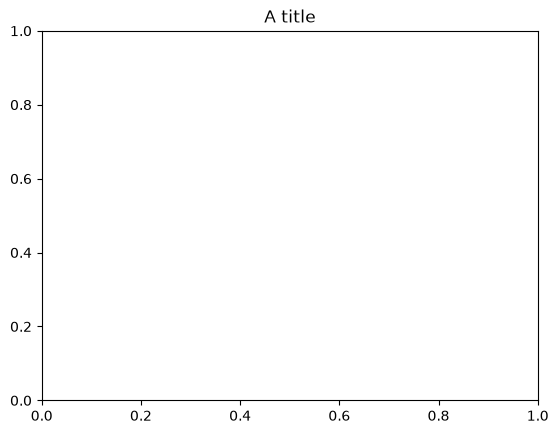

In [3]:
fig, ax = plt.subplots()
ax.set_title("A title")  # a method on an Axes object

### Anatomy of a Class

Classes are defined using `class` keyword. `__init__` runs when you create a new object, and `self` refers to that object.

In [ ]:
class MyClass:
    def __init__(self, attribute1):
        self.attribute1 = attribute1

In [ ]:
obj = MyClass(5)
obj.attribute1

You can also include functions that will be stored in the object by default too:

In [ ]:
class MyClass:
    def __init__(self, attribute1):
        self.attribute1 = attribute1

    def stringify(self, value):
        return str(value)

### Practice (5 min)

Let's work on these questions:

1. Define a class `Sample` that stores a `name` and a NumPy array of `values`.
2. Add a method `summary()` that returns the mean and standard deviation of `values`.

In [6]:
# 1.
import numpy as np

class Sample: 
    def __init__(self, name, values):
        self.name = name
        self.values = np.array(values)
        
    def summary(self):
        mean = np.mean(self.values)
        std = np.std(self.values)

        return{'mean': mean, 'std': std}


In [7]:
# 2.
my_sample = Sample('testing', [1, 2, 3, 4])

In [8]:
my_sample.summary()

{'mean': np.float64(2.5), 'std': np.float64(1.118033988749895)}

## Intro to Pandas

Pandas is a dataframe library used to load, manipulate, and analyze data.

You can think of it as a way to program a spreadsheet.

By convention, we import pandas as `pd`.

In [4]:
import pandas as pd

### Creating our first DataFrame

In [5]:
my_zoo = {
    'animal': ['panda', 'panda', 'lion', 'tiger', 'lion'],
    'sex': ['f', 'm', 'f', 'f', 'm'],
    'age': [1, 5, 2.5, 3, 3]
}

df = pd.DataFrame(my_zoo)
df

,animal,sex,age
0,panda,f,1.0
1,panda,m,5.0
2,lion,f,2.5
3,tiger,f,3.0
4,lion,m,3.0


### A DataFrame is an Object

`pd.DataFrame` is a class. Just like `MyClass(5)`, calling `pd.DataFrame(my_zoo)` creates a new object.

In [7]:
type(df)
# this is a class

pandas.DataFrame

### DataFrames and Series

DataFrames are a collection of Series. Series are a collection of values of all the same data type.

You can think of a Series conceptually as a generalized version of a `numpy.array`.

### Selecting a Column

Instead of using the index for selecting the data, we can use the column name to return the values.

This is similar to how a dictionary works. Recall from Module 1: we look up a dictionary's values by their key.

In [8]:
df['age']

0    1.0
1    5.0
2    2.5
3    3.0
4    3.0
Name: age, dtype: float64

### Series Methods

These Series have built-in methods to make sense of the data. Each of these returns a single value for the whole column.

In [9]:
df['age'].max()   # 5.0, the oldest animal

np.float64(5.0)

In [10]:
df['age'].mean()  # 2.9, the average age

np.float64(2.9)

### Practice (5 min)

Let's work on these questions:

1. Create a DataFrame from a dictionary with three columns: `sample`, `condition`, and `measurement`.
2. Select the `measurement` column and compute its `.max()` and `.mean()`.
3. Check the `type()` of your DataFrame and of the column you selected.

In [11]:
# 1.

my_dataframe = {
    'sample': ['panda', 'panda', 'lion', 'tiger', 'lion'],
    'condition': ['f', 'm', 'f', 'f', 'm'],
    'measurement': [1, 5, 2.5, 3, 3]
}


df = pd.DataFrame(my_dataframe)
df

,sample,condition,measurement
0,panda,f,1.0
1,panda,m,5.0
2,lion,f,2.5
3,tiger,f,3.0
4,lion,m,3.0


In [12]:
# 2.
df['measurement'].max()
df['measurement'].mean()


np.float64(2.9)

In [14]:
# 3.
type(df), type(df['measurement'])

(pandas.DataFrame, pandas.Series)

### Loading Data

You can also use Pandas to load data from files. `sep` refers to the separator. For this file, the columns are delimited using tabs.

Notice that you can import files using relative paths. `data/gapminder.tsv` means "the `data` folder next to this notebook, then `gapminder.tsv` inside it."

In [15]:
df = pd.read_csv('data/gapminder.tsv', sep='\t')

### Some Useful Methods

- `df.head()`: returns a view of your data. By default, it'll show you the first five rows of your data.
- `df.tail()`: similar to head but instead, it will return the last five rows of your data.

In [16]:
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [17]:
df.tail()

,country,continent,year,lifeExp,pop,gdpPercap
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298


In [18]:
df.head(10)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
5,Afghanistan,Asia,1977,38.438,14880372,786.113360
6,Afghanistan,Asia,1982,39.854,12881816,978.011439
7,Afghanistan,Asia,1987,40.822,13867957,852.395945
8,Afghanistan,Asia,1992,41.674,16317921,649.341395
9,Afghanistan,Asia,1997,41.763,22227415,635.341351


### Some Useful Attributes

- `df.columns`: returns a list of column names
- `df.shape`: returns the number of rows and number of columns of your data.
- `df.dtypes`: returns the data type of each column

Recall from Module 3: arrays have `shape` and `dtype` too.

In [19]:
df.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='str')

In [20]:
df.shape

(1704, 6)

In [21]:
df.dtypes

country          str
continent        str
year           int64
lifeExp      float64
pop            int64
gdpPercap    float64
dtype: object

### Practice (5 min)

Let's work on these questions:

1. Load `gapminder.tsv` into a DataFrame called `df`.
2. Show the first 10 rows and the last 3 rows.
3. How many rows and columns does `df` have? What is the data type of each column?

In [22]:
# 1.
df = pd.read_csv('data/gapminder.tsv', sep='\t')

In [23]:
# 2.
df.head(10), df.tail(3)

(       country continent  year  lifeExp       pop   gdpPercap
 0  Afghanistan      Asia  1952   28.801   8425333  779.445314
 1  Afghanistan      Asia  1957   30.332   9240934  820.853030
 2  Afghanistan      Asia  1962   31.997  10267083  853.100710
 3  Afghanistan      Asia  1967   34.020  11537966  836.197138
 4  Afghanistan      Asia  1972   36.088  13079460  739.981106
 5  Afghanistan      Asia  1977   38.438  14880372  786.113360
 6  Afghanistan      Asia  1982   39.854  12881816  978.011439
 7  Afghanistan      Asia  1987   40.822  13867957  852.395945
 8  Afghanistan      Asia  1992   41.674  16317921  649.341395
 9  Afghanistan      Asia  1997   41.763  22227415  635.341351,
        country continent  year  lifeExp       pop   gdpPercap
 1701  Zimbabwe    Africa  1997   46.809  11404948  792.449960
 1702  Zimbabwe    Africa  2002   39.989  11926563  672.038623
 1703  Zimbabwe    Africa  2007   43.487  12311143  469.709298)

In [26]:
# 3.
df.shape

(1704, 6)

### Selecting Data: Boolean Expressions

Recall from Module 3: `rolls == 6` gave an array of `True`/`False`.

Pandas lets you do truth evaluation for a Series in your DataFrame by writing Boolean expressions. This returns a Series that consists of `True` and `False` for the values in a given Series.

In [27]:
df['continent'] == 'Africa'

0       False
1       False
2       False
3       False
4       False
        ...  
1699     True
1700     True
1701     True
1702     True
1703     True
Name: continent, Length: 1704, dtype: bool

We can use Boolean expressions to select a subset of data from our DataFrame. It only returns the rows where the Boolean expression is true.

In [29]:
df[df['continent'] == 'Africa']
# pass in a boolean expression, returns all rows that correspond to the boolean expression being true

,country,continent,year,lifeExp,pop,gdpPercap
24,Algeria,Africa,1952,43.077,9279525,2449.008185
25,Algeria,Africa,1957,45.685,10270856,3013.976023
26,Algeria,Africa,1962,48.303,11000948,2550.816880
27,Algeria,Africa,1967,51.407,12760499,3246.991771
28,Algeria,Africa,1972,54.518,14760787,4182.663766
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


Pandas also has a convenient method for its DataFrames to write these queries. Notice that you need to provide a string to the query method.

In [31]:
df.query("continent == 'Africa'")
# ask the dataframe a question, pass in boolean expression

,country,continent,year,lifeExp,pop,gdpPercap
24,Algeria,Africa,1952,43.077,9279525,2449.008185
25,Algeria,Africa,1957,45.685,10270856,3013.976023
26,Algeria,Africa,1962,48.303,11000948,2550.816880
27,Algeria,Africa,1967,51.407,12760499,3246.991771
28,Algeria,Africa,1972,54.518,14760787,4182.663766
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


### Practice (5 min)

Let's work on these questions:

1. Select all rows for a single country, e.g. `'Kenya'`.
2. Select all rows from `2007` and save them as `df_2007`. From `df_2007`, select the countries with a `lifeExp` above 75.

In [39]:
# 1.
df[df['country'] == 'Kenya']

,country,continent,year,lifeExp,pop,gdpPercap
816,Kenya,Africa,1952,42.270,6464046,853.540919
817,Kenya,Africa,1957,44.686,7454779,944.438315
818,Kenya,Africa,1962,47.949,8678557,896.966373
819,Kenya,Africa,1967,50.654,10191512,1056.736457
820,Kenya,Africa,1972,53.559,12044785,1222.359968
821,Kenya,Africa,1977,56.155,14500404,1267.613204
822,Kenya,Africa,1982,58.766,17661452,1348.225791
823,Kenya,Africa,1987,59.339,21198082,1361.936856
824,Kenya,Africa,1992,59.285,25020539,1341.921721
825,Kenya,Africa,1997,54.407,28263827,1360.485021


In [44]:
# 2.
df_2007 = df[df['year'] == 2007]
df_2007

df_2007[df_2007['lifeExp'] > 75].head()

,country,continent,year,lifeExp,pop,gdpPercap
23,Albania,Europe,2007,76.423,3600523,5937.029526
59,Argentina,Americas,2007,75.320,40301927,12779.379640
71,Australia,Oceania,2007,81.235,20434176,34435.367440
83,Austria,Europe,2007,79.829,8199783,36126.492700
95,Bahrain,Asia,2007,75.635,708573,29796.048340


### Summary Statistics

- `.mean()`: the average of the values
- `.median()`: the middle value
- `.describe()`: the count, mean, standard deviation, min, quartiles, and max of each numeric column

In [ ]:
df['lifeExp'].mean()

In [ ]:
df['lifeExp'].median()

In [ ]:
df.describe()

### Practice (5 min)

Let's work on these questions:

1. Compute the mean and median of `lifeExp`.
2. Run `df.describe()`. Which columns show up, and which don't? Why?
3. Using Boolean indexing, compare the mean `lifeExp` in `1952` and in `2007`.

In [ ]:
# 1.


In [ ]:
# 2.


In [ ]:
# 3.


Q: What do you notice about these values? Is there a way to understand the average life expectancy for a given country?

We'll answer this with group-apply-combine in Module 6.